# exp06_viento_cielo — viento (componentes) + estado de cielo (difusa)

Sobre el multi-nodo 144 (exp05 v2) añade dos bloques pensados para los EPISODIOS:
- **viento**: componentes u/v + sin/cos de la dirección (arregla la circularidad).
- **cielo**: fracción difusa `kd=dhi/ghi` (+ tendencia) y depresión del punto de
  rocío `T−Td` — precursores baratos de nubosidad.

Se compara contra exp05 v2 (mismos 144 nodos, sin estos bloques) para AISLAR el
efecto. Reproducir: `python -m forecasting.experiments.run exp06_viento_cielo`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
import matplotlib.pyplot as plt
import pandas as pd
from forecasting.experiments.reporte import ReporteExperimento

r = ReporteExperimento.de('exp06_viento_cielo', ejecutar=False)
base = ReporteExperimento.de('exp05_multinodo_victoria', version='v2', ejecutar=False)
r.resumen(); print('--- referencia (144 sin viento/cielo) ---'); base.resumen()

exp06_viento_cielo v1 | feature-set base-nocturno-viento-cielo (52 feats) | best_iter 360
Test global: RMSE 79.00 vs persist 86.41 | skill 0.0858 | R² 0.927
--- referencia (144 sin viento/cielo) ---
exp05_multinodo_victoria v2 | feature-set base-nocturno (44 feats) | best_iter 294
Test global: RMSE 79.12 vs persist 86.41 | skill 0.0844 | R² 0.927


## ¿Ayudan las features nuevas? Comparación por régimen vs exp05 v2

La ganancia debe concentrarse en los episodios (rampa fuerte, nublado).

In [2]:
def comparar(a, b, col):
    m = a[[col,'n','skill']].merge(b[[col,'skill']], on=col, suffixes=('_144','_+vc'))
    m['delta'] = (m['skill_+vc'] - m['skill_144']).round(4)
    return m.round(3)
print('RAMPA:'); display(comparar(base.regimen_rampa, r.regimen_rampa, 'regimen_rampa'))
print('NUBOSIDAD:'); display(comparar(base.regimen_nubosidad, r.regimen_nubosidad, 'regimen_nubosidad'))

RAMPA:


,regimen_rampa,n,skill_144,skill_+vc,delta
0,rampa suave (<0.1),408158,-0.661,-0.690,-0.029
1,rampa moderada (0.1-0.25),112163,0.087,0.087,-0.000
2,rampa fuerte (>0.25),73305,0.166,0.173,0.007


NUBOSIDAD:


,regimen_nubosidad,n,skill_144,skill_+vc,delta
0,cubierto (kt<0.3),40469,-0.047,-0.044,0.002
1,parcial (0.3-0.7),104991,0.115,0.117,0.002
2,despejado (kt>=0.7),448310,0.118,0.118,0.000


## ¿Se usan las features nuevas? Importancias

`kd_difusa_lag1` (fracción difusa) suele quedar entre las más importantes.

,index,gain,rank
4,kd_difusa_lag1,0.010613,5
7,dewpoint_depresion_lag1,0.006666,8
12,wind_dir_cos_lag1,0.005669,13
19,kd_difusa_tend,0.005189,20
23,wind_dir_sin_lag1,0.004493,24
31,wind_v_lag1,0.004008,32
38,wind_u_lag1,0.002975,39
44,kd_difusa_lag2,0.002659,45


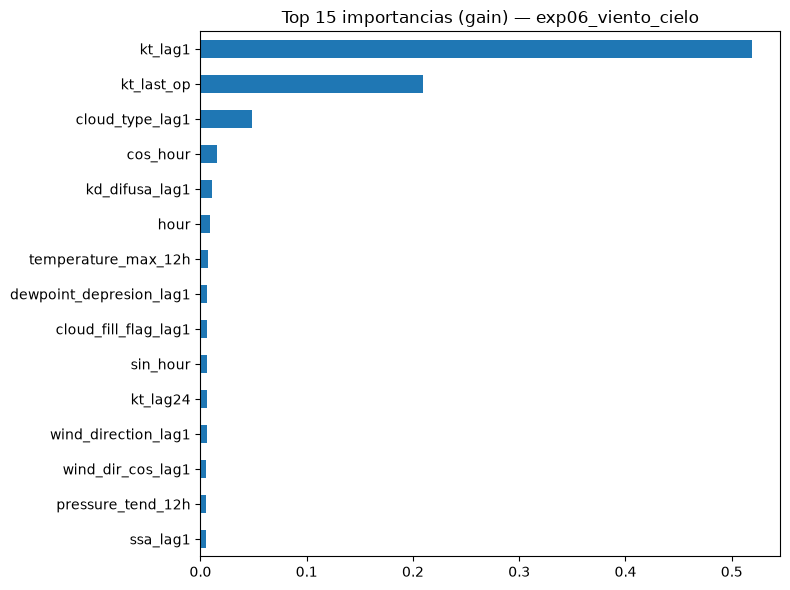

In [3]:
imp = r.importancias.reset_index(); imp['rank'] = range(1, len(imp)+1)
patron = 'wind_u|wind_v|wind_dir_sin|wind_dir_cos|kd_|dewpoint'
display(imp[imp['index'].str.contains(patron)][['index','gain','rank']])
r.plot_importancias(15); plt.tight_layout(); plt.show()

## Métricas globales y por nodo

In [4]:
display(r.metrics_global.round(3))
pn = r.por_nodo
print('skill por nodo: medio %.4f  min %.4f  max %.4f  (%d nodos)' % (
    pn.skill.mean(), pn.skill.min(), pn.skill.max(), len(pn)))

,segmento,n,RMSE_persistence,RMSE_modelo,MAE_modelo,MBE_modelo,R2_persistence,R2_modelo,skill,split
0,global,592312,86.705,78.234,43.270,4.364,0.917,0.933,0.098,val
1,limpio_ff0,539027,88.111,79.405,43.786,3.569,0.909,0.926,0.099,val
2,rellenado_ff_pos,53285,70.935,65.214,38.051,12.414,0.862,0.883,0.081,val
3,global,593770,86.414,78.996,46.696,1.754,0.913,0.927,0.086,test
4,limpio_ff0,538873,87.952,80.541,47.915,1.728,0.903,0.919,0.084,test
5,rellenado_ff_pos,54897,69.529,61.810,34.733,2.009,0.874,0.901,0.111,test


skill por nodo: medio 0.0857  min 0.0617  max 0.1058  (144 nodos)


## Series y dispersión en el nodo 1736

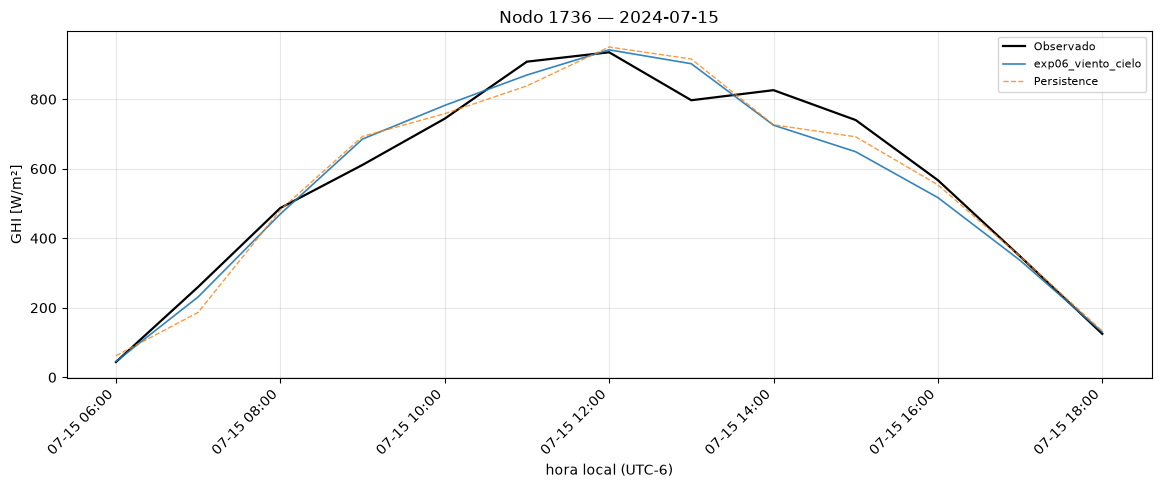

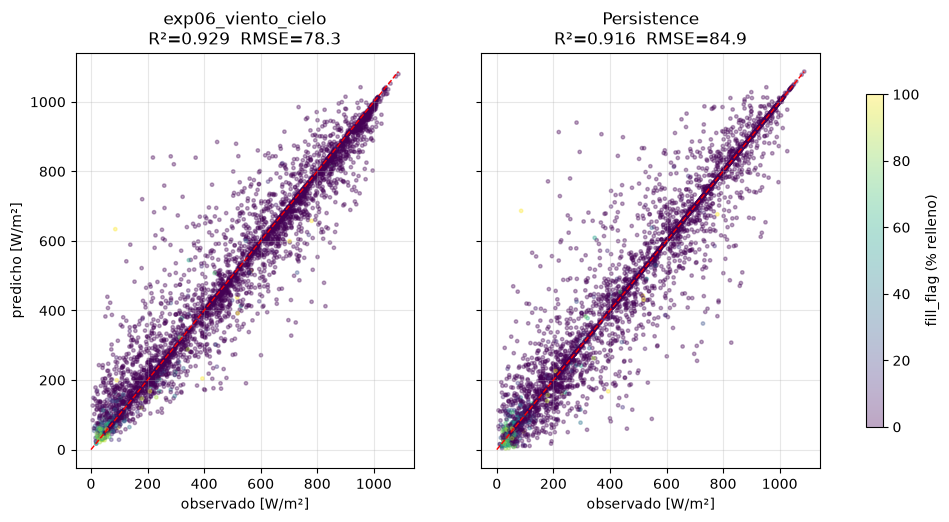

In [5]:
viz = r.visualizador(nodo=1736)
viz.serie_temporal(dia='2024-07-15'); plt.title('Nodo 1736 — 2024-07-15'); plt.show()
viz.dispersion(); plt.show()